# Multi-Modal Precipitation Prediction Model Stack

This notebook trains a multi-modal deep learning model to predict 5×5 precipitation maps from:
- **Radar**: NEXRAD reflectivity data (6 time slices, 500m resolution)
- **DEM**: Digital Elevation Model (264×264 pixels, 10m resolution)
- *(Future: LULC - Land Use/Land Cover)*

## Architecture Overview
```
Radar (25,Z,5,5) → RadarEncoder → embedding_radar
                                     ↓
                              [Decoder]
                                     ↓
                          Output: (5,5) precip map
```

Loss is computed only at gauge pixel location for supervision.


# Multi-Modal Precipitation Prediction Model

This notebook trains a multi-modal deep learning model to predict 5×5 precipitation maps from:
- **Radar**: NEXRAD reflectivity data (6 time slices, 500m resolution)
- **DEM**: Digital Elevation Model (264×264 pixels, 10m resolution)
- *(Future: LULC - Land Use/Land Cover)*


## Section 1: Setup & Imports


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Import custom dataset
import sys
sys.path.append('..')
from deep_learning.dataset_stack import RadarGaugeDataset

# Set random seeds for reproducibility
# SEED 42: MAE of 1.31
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Configure device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")



Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti


## Section 2: Model Architecture

### 2.1 RadarEncoder - CNN for Radar Data

In [3]:
class RadarEncoder(nn.Module):
    """
    CNN encoder for radar reflectivity data.
    Adapted from paper architecture for small 5×5 spatial input.
    
    Architecture:
    - Max over altitude dimension (Z) → (batch, 6, 5, 5)
    - Conv-BN-Pool-Dropout blocks (2 blocks instead of 4 due to small spatial size)
    - Flatten and FC layers
    - Output: latent embedding for fusion with DEM features
    """
    
    def __init__(self, in_channels=12, latent_dim=256, dropout_rate=0.25):
        super(RadarEncoder, self).__init__()
        
        # First conv block: 6 → 32 channels
        # Input: (24, 5, 5), Output: (32, 5, 5)
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.dropout1 = nn.Dropout2d(p=dropout_rate)
        
        # Second conv block with pooling: 32 → 64 channels
        # After conv: (64, 5, 5), After pool: (64, 2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2)  # 5×5 → 2×2
        self.dropout2 = nn.Dropout2d(p=dropout_rate)
        
        # Third conv block: 64 → 128 channels
        # Output: (128, 2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.dropout3 = nn.Dropout2d(p=dropout_rate)
        
        # Flatten: 128 * 2 * 2 = 512
        self.fc1 = nn.Linear(128 * 2 * 2, 256)
        self.dropout_fc1 = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(256, latent_dim)
        
        print(f"RadarEncoder initialized: {in_channels} channels → {latent_dim} latent dims")
    
    def forward(self, x):
        """
        Forward pass
        
        Args:
            x: (batch, 6, Z, 5, 5) radar reflectivity
            
        Returns:
            embeddings: (batch, latent_dim) feature vector
        """        

        # Conv block 1
        x = F.relu(self.bn1(self.conv1(x)))  # (batch, 32, 5, 5)
        x = self.dropout1(x)
        
        # Conv block 2 with pooling
        x = F.relu(self.bn2(self.conv2(x)))  # (batch, 64, 5, 5)
        x = self.pool2(x)                     # (batch, 64, 2, 2)
        x = self.dropout2(x)
        
        # Conv block 3
        x = F.relu(self.bn3(self.conv3(x)))  # (batch, 128, 2, 2)
        x = self.dropout3(x)
        
        # Flatten and FC layers
        x = torch.flatten(x, 1)              # (batch, 512)
        x = F.relu(self.fc1(x))              # (batch, 256)
        embeddings = self.fc2(x)             # (batch, latent_dim)
        
        return embeddings

    

### 2.4 Precipitation Decoder

In [4]:
class PrecipitationDecoder(nn.Module):
    """
    Decoder to produce 5×5 precipitation map from fused features.
    Uses LayerNorm instead of BatchNorm (works with any batch size).
    """
    
    def __init__(self, input_dim=512, hidden_dim=256, output_size=5):
        super(PrecipitationDecoder, self).__init__()
        
        self.output_size = output_size
        
        # MLP to decode fused features with LayerNorm
        self.fc1 = nn.Linear(input_dim, hidden_dim)  # 512 → 256
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.dropout1 = nn.Dropout(0.05)
        
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)  # 256 → 128
        self.ln2 = nn.LayerNorm(hidden_dim // 2)
        self.dropout2 = nn.Dropout(0.05)
        
        # Output layer: 25 values for 5×5 grid
        self.fc_out = nn.Linear(hidden_dim // 2, output_size * output_size)  # 128 → 25
        
        print(f"PrecipitationDecoder initialized: {input_dim} → {hidden_dim} → {hidden_dim // 2} → {output_size}×{output_size}")
    
    def forward(self, x):
        """Forward pass"""
        x = F.relu(self.ln1(self.fc1(x)))
        x = self.dropout1(x)
        
        x = F.relu(self.ln2(self.fc2(x)))
        x = self.dropout2(x)
        
        # Output precipitation values - NO final ReLU!
        # MSE loss will naturally encourage positive predictions
        # Removing ReLU prevents dead neurons (58.5% were stuck at 0!)
        x = self.fc_out(x)
        
        # Reshape to 5×5 grid
        x = x.view(-1, self.output_size, self.output_size)
        
        return x

### 2.5 Complete Multi-Modal Model

In [5]:
class PrecipitationDEMModel(nn.Module):
    """
    Complete model for precipitation prediction.
    
    Combines radar and DEM to predict 5×5 precipitation maps.
    """
    
    def __init__(self, latent_dim=256, n_radar_scans=12, add_bias=False):
        super(PrecipitationDEMModel, self).__init__()
        
        # Encoders
        radar_channels = n_radar_scans * 3 + 1 # a mask channel for each radar scan + dem channel
        self.radar_encoder = RadarEncoder(
            in_channels=radar_channels, 
            latent_dim=latent_dim
        )
        
        self.bias_embedding = nn.Embedding(
            num_embeddings=3,    # -1, 0, +1
            embedding_dim=32     # Small dimension
        )
        
        self.add_bias = add_bias
        # Decoder (takes encoder output + optional bias)
        if add_bias:
            decoder_input_dim = 256 + 32
        else:
            decoder_input_dim = 256
        self.decoder = PrecipitationDecoder(
            input_dim=decoder_input_dim,
            hidden_dim=512
        )
    
    def forward(self, radar, bias_flag=None):
        """
        Forward pass
        
        Args:
            radar: (batch, 25, Z, 5, 5) radar reflectivity
            
        Returns:
            precip_map: (batch, 5, 5) precipitation map in mm/hr
        """
        # Encode radar
        radar_emb = self.radar_encoder(radar)  # (batch, latent_dim)

        if bias_flag is not None:
            bias_idx = (bias_flag + 1).long()
            bias_emb = self.bias_embedding(bias_idx)
            
            combined = torch.cat([radar_emb, bias_emb], dim=1)  # (batch, 288)
            pred_map = self.decoder(combined)  # (batch, 5, 5)
        else:
            pred_map = self.decoder(radar_emb)
            
        return pred_map

### 2.6 Test Architecture with Dummy Data

In [6]:
# Test model with dummy data
print("\n=== Testing Model Architecture ===")

# Create dummy inputs matching what dataset.py returns
batch_size = 4
n_scans = 12

# Dataset returns: (24, 5, 5) = 12 radar channels + 12 mask channels
dummy_radar = torch.randn(batch_size, n_scans*3+1, 5, 5)  # (4, 24, 5, 5)
dummy_bias_flag = torch.tensor([0, 1, -1, 0])  # Mix of neutral, over, under, neutral

print(f"\nInput shapes:")
print(f"  Radar: {dummy_radar.shape}")
print(f"  Bias flags: {dummy_bias_flag.shape} (values: {dummy_bias_flag.tolist()})")

# Initialize model
model = PrecipitationDEMModel(
    n_radar_scans=12,
    latent_dim=256,
    add_bias=False
)

# Apply weight initialization
def init_weights(m):
    """Better weight initialization to prevent dead ReLUs"""
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            m.bias.data.fill_(0.01)
    elif isinstance(m, nn.Conv2d):
        torch.nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            m.bias.data.fill_(0.01)

model.apply(init_weights)
print("✓ Applied better weight initialization")

# Forward pass
model.eval()
with torch.no_grad():
    output = model(radar=dummy_radar)  # ← Pass bias_flag!

print(f"\nOutput shape: {output.shape}")
print(f"Output range: [{output.min().item():.2f}, {output.max().item():.2f}]")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\n✓ Architecture test passed!")


=== Testing Model Architecture ===

Input shapes:
  Radar: torch.Size([4, 37, 5, 5])
  Bias flags: torch.Size([4]) (values: [0, 1, -1, 0])
RadarEncoder initialized: 37 channels → 256 latent dims
PrecipitationDecoder initialized: 256 → 512 → 256 → 5×5
✓ Applied better weight initialization

Output shape: torch.Size([4, 5, 5])
Output range: [-1.36, 2.44]

Total parameters: 571,577
Trainable parameters: 571,577

✓ Architecture test passed!


In [7]:
# %%% 
# Custom collate function for DataLoader
def custom_collate(batch):
    """
    Custom collate function to handle gauge_pixel tuples and DEM properly.
    Converts list of tuples to a single tensor when all are the same.
    """
    # Extract all fields
    radar = torch.stack([item['radar'] for item in batch])
    target = torch.stack([item['target'] for item in batch])
    station_ids = [item['station_id'] for item in batch]
    hours = [item['hour'] for item in batch]
    
    # Handle gauge_pixel: convert list of tuples to tensor
    gauge_pixels = [item['gauge_pixel'] for item in batch]
    
    # Check if all gauge pixels are the same
    if all(gp == gauge_pixels[0] for gp in gauge_pixels):
        # All the same -> convert to single tensor [y, x]
        gauge_pixel = torch.tensor(gauge_pixels[0], dtype=torch.long)
    else:
        # Different locations -> stack into (batch, 2) tensor
        gauge_pixel = torch.stack([torch.tensor(gp, dtype=torch.long) for gp in gauge_pixels])
    
    # ✅ ADD THIS: Handle bias_flag
    bias_flags = [item.get('bias_flag', torch.tensor(0, dtype=torch.long)) for item in batch]
    bias_flag = torch.stack(bias_flags)
    
    return {
        'radar': radar,           
        'target': target,
        'gauge_pixel': gauge_pixel,
        'station_id': station_ids,
        'hour': hours,
        'bias_flag': bias_flag  # ✅ ADD THIS LINE!
    }

## Section 3: Loss Function

In [8]:
class GaugePixelLoss(nn.Module):
    """
    Custom loss function for precipitation prediction.
    
    Only computes loss at the gauge pixel location since that's where
    we have ground truth measurements.
    
    Handles missing data marked with -9999 sentinel value.
    Filters physically implausible outliers (> max_precip mm/hr).
    """
    
    def __init__(self, sentinel_value=-9999.0, max_precip=100.0, loss_type='mae'):
        super(GaugePixelLoss, self).__init__()
        self.sentinel_value = sentinel_value
        self.max_precip = max_precip
        self.loss_type = loss_type
        print(f"GaugePixelLoss: Filtering targets > {max_precip} mm/hr as outliers")
    
    def forward(self, pred_map, target, gauge_pixel):
        """
        Compute loss at gauge pixel location.
        
        Args:
            pred_map: (batch, 5, 5) predicted precipitation map
            target: (batch,) ground truth precipitation at gauge
            gauge_pixel: tuple (y, x), tensor [y, x], or tensor (batch, 2) with pixel locations
            
        Returns:
            loss: scalar MSE loss
        """
        batch_size = pred_map.shape[0]
        
        # Extract predictions at gauge pixel
        if isinstance(gauge_pixel, tuple):
            # All samples have same gauge pixel location (e.g., center) - tuple
            y, x = gauge_pixel
            pred_at_gauge = pred_map[:, y, x]  # (batch,)
        elif isinstance(gauge_pixel, torch.Tensor) and gauge_pixel.dim() == 1:
            # All samples have same location - tensor [y, x] from DataLoader batching
            y, x = gauge_pixel[0].item(), gauge_pixel[1].item()
            pred_at_gauge = pred_map[:, y, x]  # (batch,)
        else:
            # Each sample has different gauge pixel location
            # gauge_pixel: (batch, 2) with (y, x) for each sample
            pred_at_gauge = torch.zeros(batch_size, device=pred_map.device)
            for i in range(batch_size):
                y, x = int(gauge_pixel[i, 0].item()), int(gauge_pixel[i, 1].item())
                pred_at_gauge[i] = pred_map[i, y, x]
        
        # Filter outliers
        valid_mask = (target >= 0) & (target < np.log1p(self.max_precip))
        
        if valid_mask.sum() == 0:
            return torch.tensor(0.0, device=pred_map.device)
        
        # Choose loss metric
        if self.loss_type == 'mae':
            loss = torch.abs(pred_at_gauge[valid_mask] - target[valid_mask]).mean()
        else:  # mse
            loss = ((pred_at_gauge[valid_mask] - target[valid_mask]) ** 2).mean()
        
        return loss


# Test loss function
print("Testing loss function...")
loss_fn = GaugePixelLoss()

# Dummy predictions and targets
dummy_pred = torch.randn(4, 5, 5) * 5  # (batch, 5, 5)
dummy_target = torch.tensor([2.5, 1.0, 0.0, 3.2])  # (batch,)
gauge_pos = (2, 2)  # center pixel

test_loss = loss_fn(dummy_pred, dummy_target, gauge_pos)
print(f"Test loss: {test_loss.item():.4f}")
print("✓ Loss function works!")

Testing loss function...
GaugePixelLoss: Filtering targets > 100.0 mm/hr as outliers
Test loss: 1.7714
✓ Loss function works!


In [ ]:
def calculate_heavy_rain_metrics(predictions, targets, threshold=5.0):
    """
    Calculate hit-rate for heavy rainfall detection.
    
    Args:
        predictions: numpy array of predictions
        targets: numpy array of targets
        threshold: threshold for "heavy rain" in mm/hr
    
    Returns:
        dict with precision, recall, f1, and counts
    """
    import numpy as np
    
    # Binary classification: Is it heavy rain?
    pred_heavy = predictions > threshold
    target_heavy = targets > threshold
    
    # True positives: Predicted heavy AND actually heavy
    tp = np.sum(pred_heavy & target_heavy)
    
    # False positives: Predicted heavy BUT actually light
    fp = np.sum(pred_heavy & ~target_heavy)
    
    # False negatives: Predicted light BUT actually heavy
    fn = np.sum(~pred_heavy & target_heavy)
    
    # True negatives: Predicted light AND actually light
    tn = np.sum(~pred_heavy & ~target_heavy)
    
    # Metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'n_heavy_actual': target_heavy.sum(),
        'n_heavy_predicted': pred_heavy.sum()
    }

## Section 4: Data Loading, Balancing, & Filtering

In [9]:
from torch.utils.data import WeightedRandomSampler

def create_balanced_sampler(dataset, heavy_threshold=5.0):
    """
    Create VERY aggressive sampler to oversample heavy rain.
    """
    weights = []
    
    for idx in range(len(dataset)):
        sample = dataset.samples[idx]
        target = sample['hourly_precip_mm']
        
        # MUCH more aggressive weighting
        if target > 10.0:
            weight = 200.0  # Was probably 10-20, now 200!
        elif target > 5.0:
            weight = 100.0  # Was probably 5-10, now 100!
        elif target > 2.0:
            weight = 10.0
        elif target > 0.5:
            weight = 2.0
        else:
            weight = 1.0
        
        weights.append(weight)
    
    # Report distribution
    print("\n" + "="*60)
    print("WEIGHTED SAMPLER STATISTICS")
    print("="*60)
    print(f"Total samples: {len(weights)}")
    print(f"Extreme (>10mm) samples: {sum(1 for w in weights if w == 200.0)}")
    print(f"Heavy (5-10mm) samples:  {sum(1 for w in weights if w == 100.0)}")
    print(f"Moderate (2-5mm):        {sum(1 for w in weights if w == 10.0)}")
    print(f"\nEffective sampling rates:")
    print(f"  Extreme rain: {200.0}x more likely")
    print(f"  Heavy rain:   {100.0}x more likely")
    print(f"  Moderate:     {10.0}x more likely")
    print("="*60)
    
    sampler = WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True
    )
    
    return sampler

# validation loss ~ 0.15 (mse) R2 of .33
def create_heavy_rain_sampler(dataset):
    """
    Heavily oversample the rare heavy rain events.
    With only 4.5% heavy rain, we need aggressive weights!
    """
    targets = np.array([s['hourly_precip_mm'] for s in dataset.samples])
    
    # Create weights based on precipitation intensity
    weights = np.ones(len(targets))
    
    # Zero/trace rain: undersample slightly
    weights[targets < 0.1] = 0.5
    
    # Light rain (0.1-2mm): normal weight
    weights[(targets >= 0.1) & (targets < 2)] = 1.0
    
    # Moderate rain (2-5mm): slight oversample
    weights[(targets >= 2) & (targets < 5)] = 2.0
    
    # Heavy rain (5-15mm): moderate oversample
    weights[(targets >= 5) & (targets < 15)] = 5.0
    
    # Very heavy rain (15-40mm): heavier oversample
    weights[(targets >= 15) & (targets <= 40)] = 10.0
    
    # Normalize
    weights = weights / weights.sum() * len(weights)
    
    sampler = WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True
    )
    
    # Report effective distribution
    effective_pct = weights / weights.sum() * 100
    print(f"\n{'='*50}")
    print(f"WEIGHTED SAMPLER CREATED")
    print(f"{'='*50}")
    print(f"Category          | Original | Effective")
    print(f"------------------|----------|----------")
    print(f"Zero rain         | {(targets==0).mean()*100:5.1f}%   | {effective_pct[targets==0].sum():5.1f}%")
    print(f"Light (0-2mm)     | {((targets>0)&(targets<2)).mean()*100:5.1f}%   | {effective_pct[(targets>0)&(targets<2)].sum():5.1f}%")
    print(f"Moderate (2-5mm)  | {((targets>=2)&(targets<5)).mean()*100:5.1f}%   | {effective_pct[(targets>=2)&(targets<5)].sum():5.1f}%")
    print(f"Heavy (5-10mm)    | {((targets>=5)&(targets<10)).mean()*100:5.1f}%   | {effective_pct[(targets>=5)&(targets<10)].sum():5.1f}%")
    print(f"V.Heavy (>10mm)   | {(targets>=10).mean()*100:5.1f}%   | {effective_pct[targets>=10].sum():5.1f}%")
    print(f"{'='*50}")
    
    return sampler

# some stations consitently overestimate and others underestimate!
def filter_biased_extremes(dataset):
    OVERESTIMATING_STATIONS = [
    'Dangermond_Bunker Hill', 'Dangermond_Cistern', 'Dangermond_Cojo HQ', 'Dangermond_Jalachichi','Dangermond_Repeator'  
    ]
    UNDERESTIMATING_STATIONS = [
        'Dangermond_Cojo Gate', 'Dangermond_Sutter'
    ]

    original_count = len(dataset.samples)
    filtered = []
    removed = []

    for sample in dataset.samples:
        station_name = sample['station_name']
        target = sample['hourly_precip_mm']
        radar = sample['radar_patch']
        max_dbz = np.nanmax(radar)
        # Overestimating stations: Remove extreme high values
        # (sensor flooding - can't distinguish droplet sizes)
        if station_name in OVERESTIMATING_STATIONS:
            if target > 25.0:  # Very heavy rain
                removed.append(f"{target:.1f}mm precipitation (overestimate)")
                continue
             # Filter out
            if max_dbz > 30.0 and target < 0.3:  # Radar detects storm but gauge reads low
                removed.append(f"{target:.1f}mm precipitation (underestimate)")
                continue
    
        # Underestimating stations: Remove cases where radar says heavy but gauge says light
        # (sensor saturated/clogged)
        if station_name in UNDERESTIMATING_STATIONS:
            if max_dbz > 30.0 and target < 0.3:  # Radar detects storm but gauge reads low
                removed.append(f"{target:.1f}mm precipitation (underestimate)")
                continue
                 # Filter out
        filtered.append(sample)

    dataset.samples = filtered
    print(f"✓ Filtered {len(removed)} samples ({original_count} → {len(filtered)})")
    for r in removed[:10]:
        print(f"    - {r}")
    if len(removed) > 10:
        print(f"    ... and {len(removed)-10} more")
    
    return dataset

def filter_bad_samples(dataset):
    """Filter bad samples including ground clutter"""
    original_count = len(dataset.samples)
    filtered = []
    removed = []
    
    for sample in dataset.samples:
        target = sample['hourly_precip_mm']
        radar = sample['radar_patch']
        max_dbz = np.nanmax(radar)

        if target > 40.0:
            removed.append(f"{target:.1f}mm precipitation (sensor error)")
            continue
        
        # EXISTING: Remove radar-gauge mismatch (high rain, low radar)
        if target > 5.0 and max_dbz < 20.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (radar miss)")
            continue

        
        # If dBZ > 50 but rain < 2mm, it's likely clutter
        if max_dbz > 50.0 and target < 2.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (ground clutter)")
            continue
        
        # NEW: Remove extreme dBZ (likely always clutter)
        if max_dbz > 60.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (extreme dBZ)")
            continue
            
        filtered.append(sample)
    
    dataset.samples = filtered
    print(f"✓ Filtered {len(removed)} samples ({original_count} → {len(filtered)})")
    for r in removed[:10]:
        print(f"    - {r}")
    if len(removed) > 10:
        print(f"    ... and {len(removed)-10} more")
    
    return dataset

def filter_suspect_station_days(dataset):
    """
    Filter out samples from station-days where the station recorded ZERO
    but other stations had significant rain (likely sensor issue).
    
    Keep samples if:
    1. Station had SOME rain that day (sensor was working), OR
    2. All stations had low rain that day (genuinely dry)
    """
    # First pass: calculate daily totals per station
    daily_totals = {}
    for sample in dataset.samples:
        station = sample.get('station_name', 'Unknown')
        hour_str = str(sample.get('hour_start', ''))
        date = hour_str[:10]
        precip = sample['hourly_precip_mm']
        
        key = (station, date)
        if key not in daily_totals:
            daily_totals[key] = 0
        daily_totals[key] += precip
    
    # Calculate daily network average (excluding each station)
    date_totals = {}
    for (station, date), total in daily_totals.items():
        if date not in date_totals:
            date_totals[date] = []
        date_totals[date].append((station, total))
    
    # Identify suspect station-days
    suspect_station_days = set()
    for date, station_data in date_totals.items():
        for station, total in station_data:
            if total == 0:  # Station had zero all day
                # Calculate average of OTHER stations
                others = [t for s, t in station_data if s != station]
                others_with_rain = sum(1 for t in others if t > 2.0)
                if len(others) >= 5 and others_with_rain >= 9 and np.mean(others) > 15:  # Others had significant rain
                    suspect_station_days.add((station, date))
    
    print(f"Identified {len(suspect_station_days)} suspect station-days")
    
    
    # Filter samples
    original_count = len(dataset.samples)
    filtered = []
    removed_count = 0
    
    for sample in dataset.samples:
        station = sample.get('station_name', 'Unknown')
        hour_str = str(sample.get('hour_start', ''))
        date = hour_str[:10]
        
        if (station, date) in suspect_station_days:
            removed_count += 1
            continue
        
        filtered.append(sample)
    
    dataset.samples = filtered
    print(f"✓ Removed {removed_count} samples from suspect station-days ({original_count} → {len(filtered)})")
    
    # Show which station-days were removed
    station_day_counts = {}
    for station, date in suspect_station_days:
        short = station.replace('Dangermond_', '')
        if short not in station_day_counts:
            station_day_counts[short] = []
        station_day_counts[short].append(date)
    
    print("\nRemoved station-days:")
    for station, dates in sorted(station_day_counts.items()):
        print(f"  {station}: {len(dates)} days → {dates[:5]}{'...' if len(dates) > 5 else ''}")
    
    return dataset

## Section 5: Training Configuration

In [ ]:
model_name = "stack_bias3_weights_70_mae_nobiasflag_augment.pth"

# Hyperparameters
CONFIG = {
    'latent_dim': 256,
    'max_precip': 100.0,
    'learning_rate': 2e-4,
    'weight_decay': 1e-4,
    'num_epochs': 100,
    'patience': 20,  # Early stopping patience
    'loss_type': 'mae',
    'output_bias': 3.0,
    'add_bias_flag': True,
    'augment': True,
    'checkpoint_dir': '../checkpoints',
}

print("Training Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

# Create checkpoint directory
Path(CONFIG['checkpoint_dir']).mkdir(exist_ok=True)

#  Initialize model
model = PrecipitationDEMModel(
    latent_dim=CONFIG['latent_dim'],
    n_radar_scans=12,
    add_bias=CONFIG['add_bias_flag'],
).to(device)

# After creating model, before training:
with torch.no_grad():
    # Set decoder output bias to predict mean target value
    model.decoder.fc_out.bias.fill_(CONFIG['output_bias'])  # 🔧 Start predicting ~1mm instead of ~0

# Apply better weight initialization to prevent dead ReLUs
def init_weights(m):
    """
    Better weight initialization to prevent dead ReLUs.
    Uses Xavier for linear layers and Kaiming for conv layers.
    """
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            m.bias.data.fill_(0.01)  # Small positive bias helps ReLUs stay alive
    elif isinstance(m, nn.Conv2d):
        torch.nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            m.bias.data.fill_(0.01)

def aggressive_init_weights(m):
    """Initialize with larger weights for bolder predictions"""
    if isinstance(m, nn.Linear):
        # Use larger initialization
        nn.init.xavier_uniform_(m.weight, gain=3.0)  # 🔧 gain=2.0 instead of 1.0
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.1)  # Small positive bias

# Apply to model
model.apply(aggressive_init_weights)
print("Model reinitialized with aggressive weights")

# model.apply(init_weights)
# print("✓ Applied weight initialization to prevent dead ReLUs")

# Loss function
criterion = GaugePixelLoss(sentinel_value=-9999.0, loss_type=CONFIG['loss_type'])

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

# Learning rate scheduler (reduce on plateau)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
)

print(f"\n✓ Model and optimizer ready!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Training Configuration:
  latent_dim: 256
  max_precip: 100.0
  learning_rate: 0.0002
  weight_decay: 0.0001
  num_epochs: 100
  patience: 20
  loss_type: mae
  output_bias: 3.0
  add_bias_flag: True
  augment: True
  checkpoint_dir: ../checkpoints
RadarEncoder initialized: 37 channels → 256 latent dims
PrecipitationDecoder initialized: 288 → 512 → 256 → 5×5
Model reinitialized with aggressive weights
GaugePixelLoss: Filtering targets > 100.0 mm/hr as outliers

✓ Model and optimizer ready!
Total parameters: 587,961


In [11]:
# Configuration
DATA_PATH = './radar_gauge_dataset_9x9.pkl'  # Adjust path as needed
DEM_PATH = './preserve_dem_10m_utm.tif'
BATCH_SIZE = 8
NUM_WORKERS = 0  # Set to 0 for debugging, >0 for faster loading

# Check if data file exists
if not Path(DATA_PATH).exists():
    print(f"❌ Data file not found: {DATA_PATH}")
    print("\nPlease run: python deep_learning/prepare_radar_gauge_data.py")
    print("to create the dataset first.")
else:
    print(f"✓ Found data file: {DATA_PATH}")
    
    # Load datasets
    try:
        # Fixed (WITH DEM):
        train_dataset = RadarGaugeDataset(
            DATA_PATH, 
            dem_path=DEM_PATH,
            split='train', 
            augment=CONFIG['augment'],   
            patch_size_m=4620
            ) 
        val_dataset = RadarGaugeDataset(
            DATA_PATH,
            dem_path=DEM_PATH, 
            split='val'
            )

        train_dataset = filter_biased_extremes(train_dataset) 
        val_dataset = filter_biased_extremes(val_dataset)

        train_dataset = filter_bad_samples(train_dataset) 
        val_dataset = filter_bad_samples(val_dataset)

        train_dataset = filter_suspect_station_days(train_dataset) 
        val_dataset = filter_suspect_station_days(val_dataset)
        
        print(f"\nDataset sizes:")
        print(f"  Training: {len(train_dataset)} samples")
        print(f"  Validation: {len(val_dataset)} samples")

        train_sampler = create_heavy_rain_sampler(train_dataset)
        
        # Create DataLoaders
        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            # shuffle=True,
            sampler=train_sampler,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
            collate_fn=custom_collate
        )
        
        val_loader = DataLoader(
            val_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
            drop_last=False,
            collate_fn=custom_collate
        )
        
        print(f"\nDataLoader batches:")
        print(f"  Training: {len(train_loader)} batches")
        print(f"  Validation: {len(val_loader)} batches")
        
        # Visualize a sample batch
        print("\n=== Sample Batch ===")
        sample_batch = next(iter(train_loader))
        print(f"Radar shape: {sample_batch['radar'].shape}")
        print(f"Target shape: {sample_batch['target'].shape}")
        print(f"Gauge pixel: {sample_batch['gauge_pixel']}")
        print(f"\nTarget precipitation range: [{sample_batch['target'].min():.2f}, {sample_batch['target'].max():.2f}] mm/hr")
        
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        print("\nPlease ensure radar_gauge_dataset.pkl is properly formatted.")

✓ Found data file: ./radar_gauge_dataset_9x9.pkl
  Loading DEM from ./preserve_dem_10m_utm.tif...
  ✓ DEM loaded: shape=(1, 2763, 2527), resolution=10.0m
Loaded train dataset:
  Samples: 16264
  Radar resolution: 500m
  Patch size: 4620m
  Loading DEM from ./preserve_dem_10m_utm.tif...
  ✓ DEM loaded: shape=(1, 2763, 2527), resolution=10.0m
Loaded val dataset:
  Samples: 5999
  Radar resolution: 500m
  Patch size: 4620m
✓ Filtered 1639 samples (16264 → 14625)
    - 0.3mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    - 0.1mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    - 0.1mm precipitation (underestimate)
    ... and 1629 more
✓ Filtered 584 samples (5999 → 5415)
    - 0.0mm precipitation (underestimate)
    - 0.0mm pre

## Section 6: Training Loop

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device, epoch=0, max_precip=100.0):
    """Train for one epoch with aggressive NaN detection"""
    model.train()
    total_loss = 0
    total_mae = 0
    num_batches = 0
    
    pbar = tqdm(dataloader, desc="Training")
    
    for batch_idx, batch in enumerate(pbar):
        # Extract data
        radar = batch['radar'].to(device)
        target = batch['target'].to(device)
        gauge_pixel = batch['gauge_pixel']
        # Forward pass
        optimizer.zero_grad()
        bias_flag = batch.get('bias_flag', torch.zeros(radar.size(0))).to(device)
        if model.add_bias:
            bias_flag = batch.get('bias_flag', torch.zeros(radar.size(0))).to(device)
            pred_map = model(radar=radar, bias_flag=bias_flag)
        else:
            pred_map = model(radar=radar)
        
        # Extract prediction at gauge pixel
        if isinstance(gauge_pixel, tuple):
            y, x = gauge_pixel
            pred_at_gauge = pred_map[:, y, x]
        elif isinstance(gauge_pixel, torch.Tensor):
            if gauge_pixel.dim() == 1:
                y, x = gauge_pixel[0].item(), gauge_pixel[1].item()
                pred_at_gauge = pred_map[:, int(y), int(x)]
            else:
                batch_size = pred_map.shape[0]
                pred_at_gauge = torch.zeros(batch_size, device=device)
                for i in range(batch_size):
                    y, x = int(gauge_pixel[i, 0].item()), int(gauge_pixel[i, 1].item())
                    pred_at_gauge[i] = pred_map[i, y, x]
        
        # Compute loss
        loss = criterion(pred_map, target, gauge_pixel)
        
        # 🔍 Check loss
        if torch.isnan(loss):
            print(f"\n❌ NaN loss at batch {batch_idx}!")
            print(f"  Predictions at gauge: {pred_at_gauge}")
            print(f"  Targets: {target}")
            return float('nan'), float('nan')
        
        # Backward pass
        loss.backward()
        
        # 🔍 Check gradients BEFORE clipping
        has_nan_grad = False
        for name, param in model.named_parameters():
            if param.grad is not None and torch.isnan(param.grad).any():
                print(f"\n❌ NaN gradient in {name} at batch {batch_idx}!")
                has_nan_grad = True
                break
        
        if has_nan_grad:
            return float('nan'), float('nan')
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update weights
        optimizer.step()
        
        # 🔍 Check weights AFTER update
        if batch_idx < 3:  # Check first few batches
            for name, param in model.named_parameters():
                if torch.isnan(param).any():
                    print(f"\n❌ NaN in weights {name} after update at batch {batch_idx}!")
                    return float('nan'), float('nan')
        
        # Compute MAE in original space
        valid_mask = (target >= 0)  # All values in log-space are valid if >= 0

        if valid_mask.sum() > 0:
            # Convert to original space for MAE calculation
            pred_original = torch.expm1(pred_at_gauge[valid_mask])
            target_original = torch.expm1(target[valid_mask])
            
            # Filter outliers in original space
            outlier_mask = target_original <= max_precip
            
            if outlier_mask.sum() > 0:
                mae = torch.abs(pred_original[outlier_mask] - target_original[outlier_mask]).mean()
                total_mae += mae.item()
        # # Compute MAE
        # valid_mask = (target != criterion.sentinel_value) & (target <= max_precip)
        # if valid_mask.sum() > 0:
        #     mae = torch.abs(pred_at_gauge[valid_mask] - target[valid_mask]).mean()
        #     total_mae += mae.item()
        else:
            mae = torch.tensor(0.0)
        
        total_loss += loss.item()
        num_batches += 1
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'mae': f'{mae.item():.4f}'})
        
        # # Debug first batch
        # if epoch == 0 and num_batches == 1:
        #     print("\nGradient check:")
        #     for name, param in model.named_parameters():
        #         if param.grad is not None:
        #             grad_mean = param.grad.mean().item()
        #             grad_max = param.grad.abs().max().item()
        #             if grad_max > 0.1:  # Only show large gradients
        #                 print(f"  {name}: grad_mean={grad_mean:.6f}, grad_max={grad_max:.6f}")
    
    avg_loss = total_loss / num_batches if num_batches > 0 else float('nan')
    avg_mae = total_mae / num_batches if num_batches > 0 else float('nan')
    
    return avg_loss, avg_mae

def validate(model, dataloader, criterion, device, max_precip=100.0, heavy_threshold=5.0):
    """
    Validate the model.
    
    Returns:
        dict with: val_loss, val_mae, heavy_metrics
    """
    model.eval()
    total_loss = 0.0
    total_mae = 0.0
    num_batches = 0
    
    # 🆕 Collect all predictions and targets for heavy rain metrics
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for batch in pbar:
            # Move data to device
            radar = batch['radar'].to(device)
            target = batch['target'].to(device)
            gauge_pixel = batch['gauge_pixel']
            bias_flag = batch.get('bias_flag', torch.zeros(radar.size(0))).to(device)
            if model.add_bias:
                bias_flag = batch.get('bias_flag', torch.zeros(radar.size(0))).to(device)
                pred_map = model(radar=radar, bias_flag=bias_flag)
            else:
                pred_map = model(radar=radar)
            
            # Compute loss
            loss = criterion(pred_map, target, gauge_pixel)
                       
            # Extract predictions at gauge pixel
            if isinstance(gauge_pixel, tuple):
                y, x = gauge_pixel
                pred_at_gauge = pred_map[:, y, x]
            elif isinstance(gauge_pixel, torch.Tensor) and gauge_pixel.dim() == 1:
                y, x = gauge_pixel[0].item(), gauge_pixel[1].item()
                pred_at_gauge = pred_map[:, y, x]
            else:
                pred_at_gauge = torch.zeros_like(target)
                for i in range(len(target)):
                    y, x = int(gauge_pixel[i, 0].item()), int(gauge_pixel[i, 1].item())
                    pred_at_gauge[i] = pred_map[i, y, x]
            
            # Filter valid samples
            # valid_mask = (target != -9999.0) & (target <= max_precip)
            
            # if valid_mask.sum() > 0:
            #     mae = torch.abs(pred_at_gauge[valid_mask] - target[valid_mask]).mean()
            #     total_mae += mae.item()
            valid_mask = (target >= 0)  # In log-space, all valid targets are >= 0

            if valid_mask.sum() > 0:
                # Convert from log-space to original space
                pred_original = torch.expm1(pred_at_gauge[valid_mask])  # exp(x) - 1
                target_original = torch.expm1(target[valid_mask])       # exp(x) - 1
                
                # Filter outliers in ORIGINAL space
                outlier_mask = target_original <= max_precip
                
                if outlier_mask.sum() > 0:
                    mae = torch.abs(pred_original[outlier_mask] - target_original[outlier_mask]).mean()
                    total_mae += mae.item()

                
                # 🆕 Store valid predictions and targets
                all_preds.append(pred_original[outlier_mask].cpu())
                all_targets.append(target_original[outlier_mask].cpu())
                
            total_loss += loss.item()
            num_batches += 1
            
            # Update progress bar
            pbar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / num_batches if num_batches > 0 else 0
    avg_mae = total_mae / num_batches if num_batches > 0 else 0
    
    # 🆕 Calculate heavy rain metrics
    if len(all_preds) > 0:
        all_preds = torch.cat(all_preds).numpy()
        all_targets = torch.cat(all_targets).numpy()
        
        heavy_metrics = calculate_heavy_rain_metrics(
            all_preds, 
            all_targets, 
            threshold=heavy_threshold
        )
    else:
        heavy_metrics = None
    
    return {
        'loss': avg_loss,
        'mae': avg_mae,
        'heavy_metrics': heavy_metrics
    }


In [ ]:
# Training loop
print("\n=== Starting Training ===")

best_val_loss = float('inf')
patience_counter = 0
history = {
    'train_loss': [],
    'train_mae': [],
    'val_loss': [],
    'val_mae': []
}

for epoch in range(CONFIG['num_epochs']):
    print(f"\nEpoch {epoch+1}/{CONFIG['num_epochs']}")
    print("-" * 50)
    
    # Train (pass max_precip!)
    train_loss, train_mae = train_epoch(
        model, train_loader, criterion, optimizer, device, 
        epoch=epoch, max_precip=criterion.max_precip
    )

    heavy_threshold = 10.0
    
    # Validate (pass max_precip!)
    val_results = validate(
        model, 
        val_loader, 
        criterion,  
        device, 
        max_precip=CONFIG['max_precip'],
        heavy_threshold=heavy_threshold  # Adjust this based on your needs
    )

    val_loss = val_results['loss']
    val_mae = val_results['mae']
    heavy_metrics = val_results['heavy_metrics']

    
    # Learning rate scheduler
    scheduler.step(val_loss)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_mae'].append(train_mae)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train MAE: {train_mae:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.4f}")
    
    if heavy_metrics:
        print(f"  Heavy Rain (>{heavy_threshold}mm/hr):")
        print(f"    Precision: {heavy_metrics['precision']:.2%} ({heavy_metrics['tp']}/{heavy_metrics['tp']+heavy_metrics['fp']})")
        print(f"    Recall:    {heavy_metrics['recall']:.2%} ({heavy_metrics['tp']}/{heavy_metrics['tp']+heavy_metrics['fn']})")
        print(f"    F1 Score:  {heavy_metrics['f1']:.2%}")
        print(f"    Actual heavy events: {heavy_metrics['n_heavy_actual']}")

    # 🔬 Detailed prediction analysis
    print("\n" + "="*70)
    print("PREDICTION DISTRIBUTION ANALYSIS")
    print("="*70)

    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in val_loader:
            radar = batch['radar'].to(device)
            target = batch['target'].to(device)
            gauge_pixel = batch['gauge_pixel']
            bias_flag = batch.get('bias_flag', torch.zeros(radar.size(0))).to(device)
            if model.add_bias:
                bias_flag = batch.get('bias_flag', torch.zeros(radar.size(0))).to(device)
                pred_map = model(radar=radar, bias_flag=bias_flag)
            else:
                pred_map = model(radar=radar)
            
            # Extract at gauge pixels
            if gauge_pixel.dim() == 1:
                y, x = gauge_pixel[0].item(), gauge_pixel[1].item()
                pred_at_gauge = pred_map[:, y, x]
            else:
                batch_indices = torch.arange(len(target), device=device)
                y = gauge_pixel[:, 0]
                x = gauge_pixel[:, 1]
                pred_at_gauge = pred_map[batch_indices, y, x]
            
            # Filter valid
            valid_mask = (target >= 0) & (target < 100.0)

            pred_original = torch.expm1(pred_at_gauge[valid_mask])
            target_original = torch.expm1(target[valid_mask])
            
            all_preds.append(pred_original.cpu())
            all_targets.append(target_original.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    print(f"\n📊 VALIDATION PREDICTIONS:")
    print(f"  Total samples: {len(all_preds)}")
    print(f"  Pred Mean:  {all_preds.mean():.4f} mm/hr")
    print(f"  Pred Std:   {all_preds.std():.4f} mm/hr")
    print(f"  Pred Min:   {all_preds.min():.4f} mm/hr")
    print(f"  Pred Max:   {all_preds.max():.4f} mm/hr")
    print(f"  Pred Median: {np.median(all_preds):.4f} mm/hr")

    print(f"\n📊 VALIDATION TARGETS:")
    print(f"  Target Mean:  {all_targets.mean():.4f} mm/hr")
    print(f"  Target Std:   {all_targets.std():.4f} mm/hr")
    print(f"  Target Min:   {all_targets.min():.4f} mm/hr")
    print(f"  Target Max:   {all_targets.max():.4f} mm/hr")

    print(f"\n🌧️  HEAVY RAIN BREAKDOWN:")
    for threshold in [1.0, 2.0, 5.0, 10.0, 20.0]:
        n_pred = (all_preds > threshold).sum()
        n_actual = (all_targets > threshold).sum()
        print(f"  >{threshold:5.1f} mm/hr: Pred={n_pred:4d} ({100*n_pred/len(all_preds):5.1f}%), "
            f"Actual={n_actual:4d} ({100*n_actual/len(all_targets):5.1f}%)")

    print(f"\n🎯 PERCENTILES:")
    for p in [50, 75, 90, 95, 99]:
        pred_p = np.percentile(all_preds, p)
        target_p = np.percentile(all_targets, p)
        print(f"  {p}th: Pred={pred_p:6.3f}, Target={target_p:6.3f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        
        checkpoint_path = Path(CONFIG['checkpoint_dir']) / model_name
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_mae': val_mae,
            'config': CONFIG
        }, checkpoint_path)
        
        print(f"  ✓ Saved best model (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{CONFIG['patience']})")
    
    # Early stopping
    if patience_counter >= CONFIG['patience']:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print("\n=== Training Complete ===")
print(f"Best validation loss: {best_val_loss:.4f}")


## Section 7: Post-Training Diagnostics

Let's check if the model is actually learning or just predicting the mean.

In [14]:
# Right after training loop ends
print("\n" + "="*70)
print("POST-TRAINING ANALYSIS")
print("="*70)

# Use the TRAINED model that was just loaded with best weights
all_preds = []
all_targets = []

# Load best model checkpoint
print("Loading best model for post-training analysis...")
checkpoint = torch.load(f'../checkpoints/stack_99_bias3_weights_70_mae_biasflag_augment.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

with torch.no_grad():
    for batch in val_loader:
        radar = batch['radar'].to(device)
        target = batch['target'].to(device)
        gauge_pixel = batch['gauge_pixel']
        bias_flag = batch.get('bias_flag', torch.zeros(radar.size(0))).to(device)
        if model.add_bias:
            bias_flag = batch.get('bias_flag', torch.zeros(radar.size(0))).to(device)
            pred_map = model(radar=radar, bias_flag=bias_flag)
        else:
            pred_map = model(radar=radar)

        
        # Extract at gauge pixels
        if gauge_pixel.dim() == 1:
            y, x = gauge_pixel[0].item(), gauge_pixel[1].item()
            pred_at_gauge = pred_map[:, y, x]
        else:
            batch_indices = torch.arange(len(target), device=device)
            y = gauge_pixel[:, 0]
            x = gauge_pixel[:, 1]
            pred_at_gauge = pred_map[batch_indices, y, x]
        
        valid_mask = (target >= 0) & (target < 5)
        pred_original = torch.expm1(pred_at_gauge[valid_mask])
        target_original = torch.expm1(target[valid_mask])

        all_preds.append(pred_original.cpu())
        all_targets.append(target_original.cpu())

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

print(f"Pred Max: {all_preds.max():.2f} mm/hr")  # ← Should be >5mm!
print(f"Pred Mean: {all_preds.mean():.2f} mm/hr")
print(f"# Predictions >5mm: {(all_preds > 5).sum()}")


POST-TRAINING ANALYSIS
Loading best model for post-training analysis...
Pred Max: 7.18 mm/hr
Pred Mean: 0.45 mm/hr
# Predictions >5mm: 71


### Plot Training History

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history['train_mae'], label='Train MAE', marker='o', color='orange')
axes[1].plot(history['val_mae'], label='Val MAE', marker='s', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (mm/hr)')
axes[1].set_title('Mean Absolute Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CONFIG['checkpoint_dir']) / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

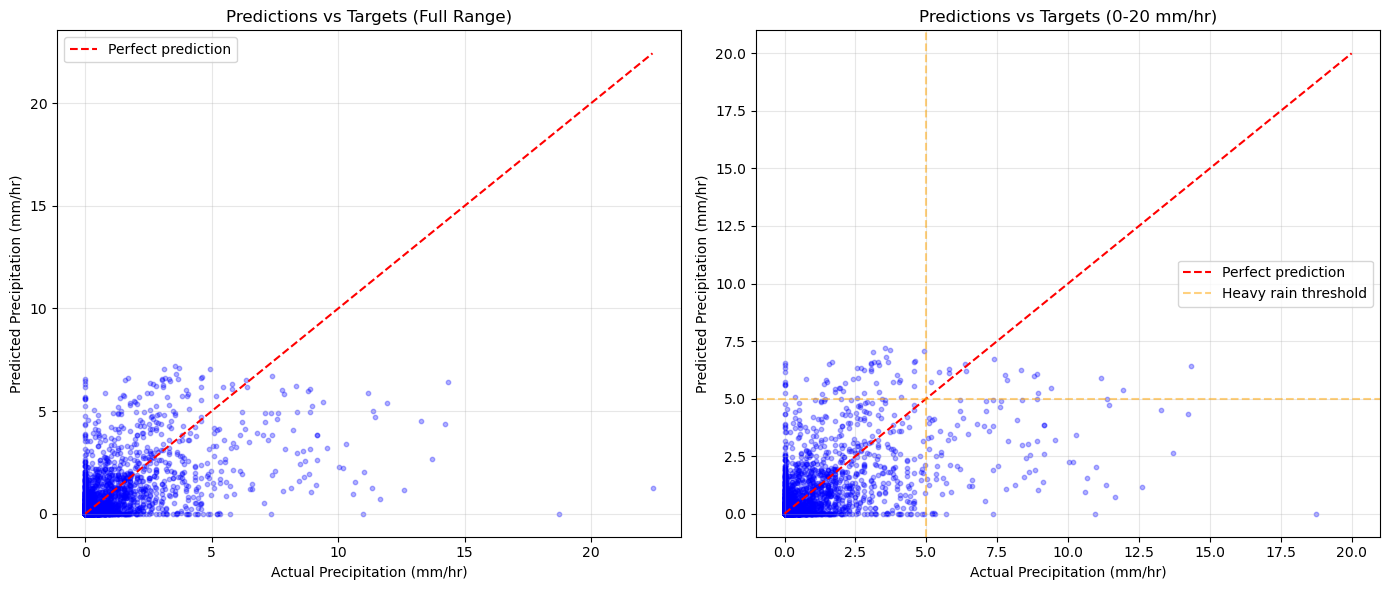


📊 Scatter Plot Analysis:
  Points above red line: Model overpredicting
  Points below red line: Model underpredicting
  Cluster near (0,0): Dry/light rain samples
CORRELATION ANALYSIS
Pearson r:  0.575 (p=0.00e+00)
Spearman r: 0.574 (p=0.00e+00)
R-squared:  0.330

→ Model explains 33.0% of variance in precipitation


In [15]:
# Scatter plot: Predicted vs Actual
import matplotlib.pyplot as plt
import numpy as np

# Use the all_preds and all_targets from POST-TRAINING ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Full range
axes[0].scatter(all_targets, all_preds, alpha=0.3, s=10, c='blue')
axes[0].plot([0, all_targets.max()], [0, all_targets.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual Precipitation (mm/hr)')
axes[0].set_ylabel('Predicted Precipitation (mm/hr)')
axes[0].set_title('Predictions vs Targets (Full Range)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Zoomed to 0-20 mm/hr
mask_zoom = all_targets <= 20
axes[1].scatter(all_targets[mask_zoom], all_preds[mask_zoom], alpha=0.3, s=10, c='blue')
axes[1].plot([0, 20], [0, 20], 'r--', label='Perfect prediction')
axes[1].axhline(y=5, color='orange', linestyle='--', alpha=0.5, label='Heavy rain threshold')
axes[1].axvline(x=5, color='orange', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Actual Precipitation (mm/hr)')
axes[1].set_ylabel('Predicted Precipitation (mm/hr)')
axes[1].set_title('Predictions vs Targets (0-20 mm/hr)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Scatter Plot Analysis:")
print(f"  Points above red line: Model overpredicting")
print(f"  Points below red line: Model underpredicting")
print(f"  Cluster near (0,0): Dry/light rain samples")

from scipy.stats import pearsonr, spearmanr

# Calculate correlations
pearson_r, pearson_p = pearsonr(all_targets, all_preds)
spearman_r, spearman_p = spearmanr(all_targets, all_preds)

print("=" * 50)
print("CORRELATION ANALYSIS")
print("=" * 50)
print(f"Pearson r:  {pearson_r:.3f} (p={pearson_p:.2e})")
print(f"Spearman r: {spearman_r:.3f} (p={spearman_p:.2e})")

# R-squared
r_squared = pearson_r ** 2
print(f"R-squared:  {r_squared:.3f}")
print(f"\n→ Model explains {r_squared*100:.1f}% of variance in precipitation")

RadarEncoder initialized: 37 channels → 256 latent dims
PrecipitationDecoder initialized: 288 → 512 → 256 → 5×5
Model reinitialized with aggressive weights
Loading model from checkpoint: ../checkpoints/stack_99_bias3_weights_70_mae_biasflag_augment.pth
  Loaded epoch 20, val_mae=0.449

Loading test dataset: ../deep_learning/radar_gauge_test_daily_9x9.pkl
Total hourly samples: 4743
Gauge type: daily_cumulative
Grouped into 208 unique day-station combinations

Evaluating on 208 days...


Days: 100%|██████████| 208/208 [00:06<00:00, 29.76it/s]



DAILY TEST SET RESULTS
  Samples: 208 day-station combinations
  MAE:  10.78 mm/day
  RMSE: 17.10 mm/day
  R²:   0.261

Worst predictions:
  2025-02-05 Dangermond Wood Canyon   : pred= 16.9, truth= 87.4, error= -70.4
  2025-11-14 Dangermond Wood Canyon   : pred= 31.6, truth= 88.7, error= -57.1
  2025-11-14 Dangermond Oaks 1        : pred= 29.5, truth= 84.0, error= -54.5
  2025-11-14 Dangermond Escondido 2   : pred= 32.3, truth= 86.0, error= -53.7
  2025-11-14 Dangermond Oaks 5        : pred= 23.9, truth= 75.0, error= -51.1


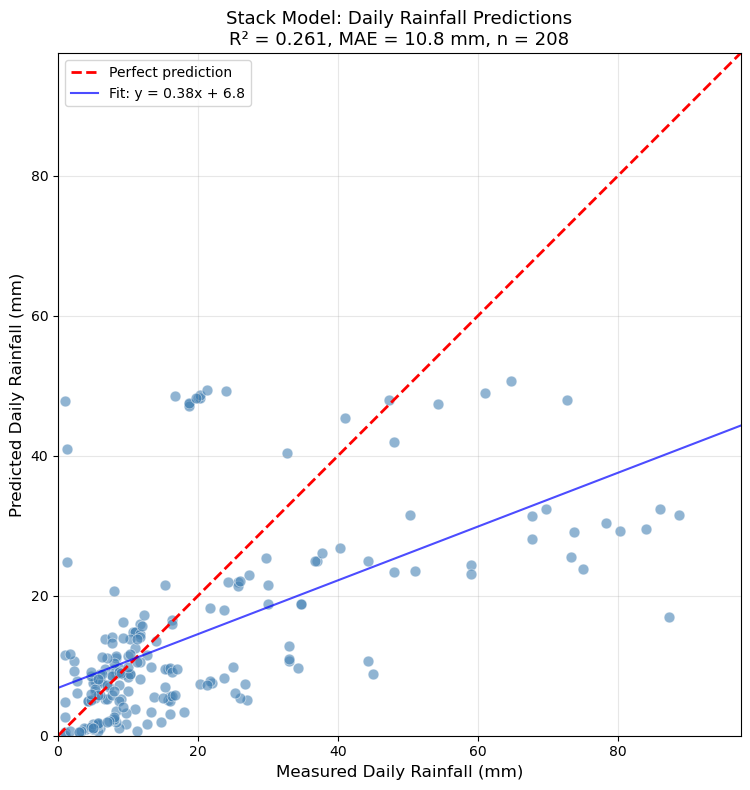


Prediction stats:
  Mean truth: 19.1 mm
  Mean pred:  14.2 mm
  Correlation: 0.576


In [22]:
# =============================================================================
# SECTION: EVALUATE ON DAILY TEST SET
# =============================================================================
# This evaluates the model on daily rainfall gauges (independent test set)
# 
# Default: Uses model already in memory after training
# Optional: Load from checkpoint by setting LOAD_FROM_CHECKPOINT = True
# =============================================================================

import pickle
from collections import defaultdict

# === CONFIGURATION ===
LOAD_FROM_CHECKPOINT = True  # Set True to load from saved checkpoint
CHECKPOINT_PATH = f"../checkpoints/stack_99_bias3_weights_70_mae_biasflag_augment.pth"  # Only used if above is True
TEST_DATASET_PATH = '../deep_learning/radar_gauge_test_daily_9x9.pkl'

if LOAD_FROM_CHECKPOINT:
    #  Initialize model
    model = PrecipitationDEMModel(
        latent_dim=CONFIG['latent_dim'],
        n_radar_scans=12,
        add_bias=True
    ).to(device)

    # After creating model, before training:
    with torch.no_grad():
        # Set decoder output bias to predict mean target value
        model.decoder.fc_out.bias.fill_(3.0)  # 🔧 Start predicting ~1mm instead of ~0

    # Apply better weight initialization to prevent dead ReLUs
    def init_weights(m):
        """
        Better weight initialization to prevent dead ReLUs.
        Uses Xavier for linear layers and Kaiming for conv layers.
        """
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                m.bias.data.fill_(0.01)  # Small positive bias helps ReLUs stay alive
        elif isinstance(m, nn.Conv2d):
            torch.nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                m.bias.data.fill_(0.01)

    def aggressive_init_weights(m):
        """Initialize with larger weights for bolder predictions"""
        if isinstance(m, nn.Linear):
            # Use larger initialization
            nn.init.xavier_uniform_(m.weight, gain=3.0)  # 🔧 gain=2.0 instead of 1.0
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.1)  # Small positive bias

    # Apply to model
    model.apply(aggressive_init_weights)
    print("Model reinitialized with aggressive weights")


    print(f"Loading model from checkpoint: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"  Loaded epoch {checkpoint.get('epoch', 'N/A')}, val_mae={checkpoint.get('val_mae', 'N/A'):.3f}")

model.eval()

# === Load test dataset ===
print(f"\nLoading test dataset: {TEST_DATASET_PATH}")
with open(TEST_DATASET_PATH, 'rb') as f:
    test_data = pickle.load(f)

print(f"Total hourly samples: {len(test_data['test'])}")
print(f"Gauge type: {test_data['metadata']['gauge_type']}")

# Group samples by (date, station_id)
daily_groups = defaultdict(list)
for sample in test_data['test']:
    key = (sample['date'], sample['station_id'], sample['station_name'])
    daily_groups[key].append(sample)

print(f"Grouped into {len(daily_groups)} unique day-station combinations")

# === Preprocessing function (matches training exactly!) ===
def prepare_test_input(sample):
    """Prepare input - matches RadarGaugeDataset.__getitem__ for 9×9 patches"""
    DBZ_MIN = -32.0
    DBZ_MAX = 70.0
    
    radar_patch = sample['radar_patch'].copy()  # (12, 40, 9, 9)
    
    # Determine patch size and center crop if needed
    input_size = radar_patch.shape[-1]  # 9 for 9×9
    output_size = 5
    
    if input_size > output_size:
        # Center crop from 9×9 to 5×5
        offset = (input_size - output_size) // 2  # = 2
        radar_patch = radar_patch[:, :, offset:offset+output_size, offset:offset+output_size]
    
    # Handle missing data
    radar_patch = np.where(radar_patch == -9999.0, DBZ_MIN, radar_patch)
    radar_patch = np.where(np.isnan(radar_patch), DBZ_MIN, radar_patch)
    
    # Normalize to [0, 1]
    radar_norm = (radar_patch - DBZ_MIN) / (DBZ_MAX - DBZ_MIN)
    radar_norm = np.clip(radar_norm, 0, 1)
    
    # Create mask
    mask = np.ones_like(radar_norm)
    for i, ridx in enumerate(sample.get('radar_indices', [])):
        if ridx is None:
            mask[i, :, :, :] = 0.0
            radar_norm[i, :, :, :] = 0.0
    
    # Convert to tensors
    radar_t = torch.from_numpy(radar_norm).float()
    mask_t = torch.from_numpy(mask).float()
    
    # Max over Z dimension
    radar_maxz, _ = torch.max(radar_t, dim=1)  # (12, 5, 5)
    mask_maxz, _ = torch.max(mask_t, dim=1)    # (12, 5, 5)
    
    # Temporal position channels
    t_pos = torch.zeros_like(radar_maxz)
    for i in range(12):
        t_pos[i] = i / 11.0
    
    # DEM - for test we just use zeros since we don't have it stored
    # (or load on-the-fly if you want)
    dem_downsampled = torch.zeros(1, 5, 5)
    
    # Concatenate all: 12 + 12 + 12 + 1 = 37 channels
    radar_input = torch.cat([radar_maxz, mask_maxz, t_pos, dem_downsampled], dim=0)
    
    return radar_input.unsqueeze(0).to(device)

    
# === Run evaluation ===
print(f"\nEvaluating on {len(daily_groups)} days...")
results = []

with torch.no_grad():
    for (date, station_id, station_name), hourly_samples in tqdm(daily_groups.items(), desc="Days"):
        hourly_preds = []
        daily_truth = hourly_samples[0]['daily_precip_mm']
        
        for sample in hourly_samples:
            radar = prepare_test_input(sample)
            bias = torch.tensor([1], dtype=torch.long, device=device)  # Neutral bias
            if model.add_bias:
                pred_log = model(radar, bias)  # Output is in log space!
            else:
                pred_log = model(radar)
            pred_center_log = pred_log[0, 2, 2].item()
            pred_mm = np.expm1(pred_center_log)  # Convert back to mm/hr
            hourly_preds.append(max(0, pred_mm))
        
        daily_pred = sum(hourly_preds)
        
        results.append({
            'date': date,
            'station_name': station_name,
            'n_hours': len(hourly_preds),
            'daily_pred': daily_pred,
            'daily_truth': daily_truth,
            'error': daily_pred - daily_truth,
        })

# === Print metrics ===
preds = np.array([r['daily_pred'] for r in results])
truths = np.array([r['daily_truth'] for r in results])

mae = np.mean(np.abs(preds - truths))
rmse = np.sqrt(np.mean((preds - truths)**2))
ss_res = np.sum((truths - preds)**2)
ss_tot = np.sum((truths - np.mean(truths))**2)
r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

print(f"\n{'='*60}")
print(f"DAILY TEST SET RESULTS")
print(f"{'='*60}")
print(f"  Samples: {len(results)} day-station combinations")
print(f"  MAE:  {mae:.2f} mm/day")
print(f"  RMSE: {rmse:.2f} mm/day")
print(f"  R²:   {r2:.3f}")

# Show worst predictions
print(f"\nWorst predictions:")
sorted_results = sorted(results, key=lambda x: abs(x['error']), reverse=True)
for r in sorted_results[:5]:
    print(f"  {r['date']} {r['station_name'][:25]:25s}: pred={r['daily_pred']:5.1f}, truth={r['daily_truth']:5.1f}, error={r['error']:+6.1f}")


# === SCATTER PLOT WITH R² ===
import matplotlib.pyplot as plt
import numpy as np

preds = np.array([r['daily_pred'] for r in results])
truths = np.array([r['daily_truth'] for r in results])

fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot
ax.scatter(truths, preds, alpha=0.6, s=60, c='steelblue', edgecolors='white', linewidth=0.5)

# Perfect prediction line
max_val = max(truths.max(), preds.max()) * 1.1
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')

# Fit line
z = np.polyfit(truths, preds, 1)
p = np.poly1d(z)
ax.plot([0, max_val], [p(0), p(max_val)], 'b-', alpha=0.7, linewidth=1.5, label=f'Fit: y = {z[0]:.2f}x + {z[1]:.1f}')

# Labels
ax.set_xlabel('Measured Daily Rainfall (mm)', fontsize=12)
ax.set_ylabel('Predicted Daily Rainfall (mm)', fontsize=12)
ax.set_title(f'Stack Model: Daily Rainfall Predictions\nR² = {r2:.3f}, MAE = {mae:.1f} mm, n = {len(results)}', fontsize=13)
ax.legend(loc='upper left')
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Also print some stats
print(f"\nPrediction stats:")
print(f"  Mean truth: {truths.mean():.1f} mm")
print(f"  Mean pred:  {preds.mean():.1f} mm")
print(f"  Correlation: {np.corrcoef(truths, preds)[0,1]:.3f}")

=== LINEAR FIT ANALYSIS ===
Fit: truth = 0.863 × pred + 6.90
Correlation R²: 0.332
Standard R²:    0.261
Slope: 0.863
Intercept: 6.90 mm/day
P-value: 9.22e-20

=== AFTER CALIBRATION ===
R² (calibrated):  0.332
MAE (calibrated): 10.92 mm/day


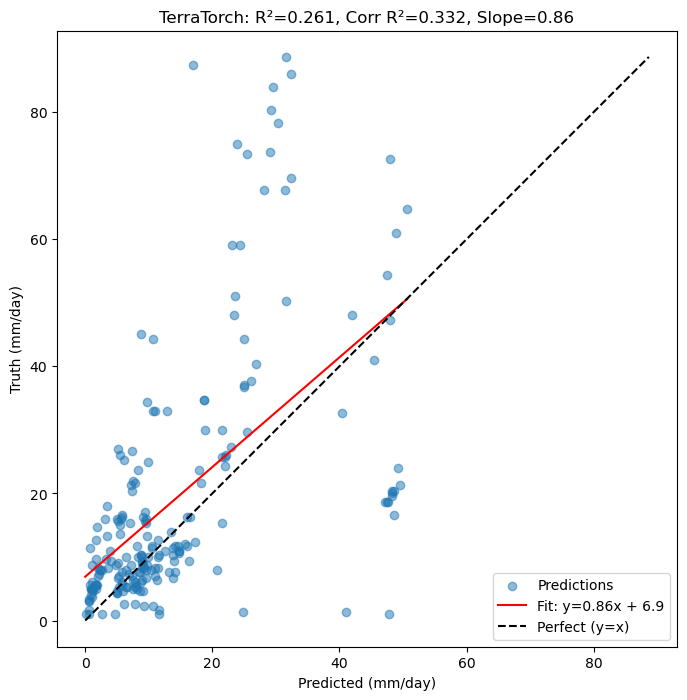

In [23]:
from scipy import stats

# Fit: truth = slope * pred + intercept
slope, intercept, r_value, p_value, std_err = stats.linregress(preds, truths)

print("=== LINEAR FIT ANALYSIS ===")
print(f"Fit: truth = {slope:.3f} × pred + {intercept:.2f}")
print(f"Correlation R²: {r_value**2:.3f}")  # How well predictions track with truth
print(f"Standard R²:    {r2:.3f}")          # Your original R²
print(f"Slope: {slope:.3f}")
if slope > 1:
    print(f"  → Model underpredicts by ~{slope:.1f}x")
print(f"Intercept: {intercept:.2f} mm/day")
print(f"P-value: {p_value:.2e}")

# Calibrated predictions
preds_calibrated = slope * preds + intercept
ss_res_cal = np.sum((truths - preds_calibrated)**2)
r2_calibrated = 1 - (ss_res_cal / ss_tot)
mae_calibrated = np.mean(np.abs(preds_calibrated - truths))

print(f"\n=== AFTER CALIBRATION ===")
print(f"R² (calibrated):  {r2_calibrated:.3f}")
print(f"MAE (calibrated): {mae_calibrated:.2f} mm/day")

# Scatter plot with fit line
plt.figure(figsize=(8, 8))
plt.scatter(preds, truths, alpha=0.5, label='Predictions')
plt.plot([0, max(preds)], [intercept, slope*max(preds) + intercept], 'r-', 
         label=f'Fit: y={slope:.2f}x + {intercept:.1f}')
plt.plot([0, max(truths)], [0, max(truths)], 'k--', label='Perfect (y=x)')
plt.xlabel('Predicted (mm/day)')
plt.ylabel('Truth (mm/day)')
plt.title(f'TerraTorch: R²={r2:.3f}, Corr R²={r_value**2:.3f}, Slope={slope:.2f}')
plt.legend()
plt.axis('equal')
plt.show()

In [24]:
def visualize_stack_sample(sample_or_batch, from_loader=True, sample_idx=0, model=None, device='cuda'):
    """
    Visualize a single training sample for Stack model with optional predictions
    
    Parameters:
    -----------
    sample_or_batch : dict
        Batch from DataLoader
    from_loader : bool
        If True, expects batch from DataLoader
    sample_idx : int
        Which sample in batch to visualize
    model : torch.nn.Module, optional
        If provided, show model predictions
    device : str
        Device for model inference
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import torch
    
    if from_loader:
        # Extract from batch
        radar_input = sample_or_batch['radar'][sample_idx]  # (37, 5, 5)
        target = sample_or_batch['target'][sample_idx].item()
        
        # Separate channels
        radar_maxz = radar_input[:12]      # (12, 5, 5) - max reflectivity
        mask = radar_input[12:24]          # (12, 5, 5) - validity mask
        t_pos = radar_input[24:36]         # (12, 5, 5) - temporal position
        dem = radar_input[36]              # (5, 5) - DEM
    
    # Get model prediction if model provided
    # Get model prediction if model provided
    pred_map = None
    pred_center = None
    if model is not None:
        model.eval()
        with torch.no_grad():
            radar_batch = sample_or_batch['radar'][sample_idx:sample_idx+1].to(device)
            
            # Check if model uses bias flag
            if hasattr(model, 'add_bias') and model.add_bias:
                # FIX: Also slice the bias_flag from the batch!
                if 'bias_flag' in sample_or_batch:
                    bias_flag = sample_or_batch['bias_flag'][sample_idx:sample_idx+1].to(device)
                else:
                    # Default to neutral bias (1 = no bias)
                    bias_flag = torch.ones(1, dtype=torch.long).to(device)
                
                pred_map_log = model(radar=radar_batch, bias_flag=bias_flag)
            else:
                pred_map_log = model(radar=radar_batch)
            
            # DEBUG: Print shapes
            print(f"Model output shape: {pred_map_log.shape}")
            print(f"Model output sample:\n{pred_map_log[0]}")
            
            # The model outputs (batch, 5, 5) in log space
            # If output is (batch, 1, 5, 5), squeeze the channel dim
            if pred_map_log.dim() == 4:
                pred_map_log = pred_map_log.squeeze(1)  # Remove channel dim
                print(f"After squeeze: {pred_map_log.shape}")
            
            # Convert from log space
            pred_map = torch.expm1(pred_map_log[0]).cpu().numpy()  # (5, 5)
            pred_center = pred_map[2, 2]  # Center pixel
            
            print(f"Pred_map shape: {pred_map.shape}")
            print(f"Pred_map:\n{pred_map}")
    
    # Create visualization with 4 columns
    n_rows = 5 if model is not None else 4  # Add extra row for predictions
    fig = plt.figure(figsize=(16, 3*n_rows))
    gs = fig.add_gridspec(n_rows, 4, hspace=0.3, wspace=0.3)
    
    # Row 0-2: Radar reflectivity at each time step (12 scans, 4 per row)
    for t in range(12):
        ax = fig.add_subplot(gs[t // 4, t % 4])
        im = ax.imshow(radar_maxz[t].cpu().numpy(), 
                      cmap='turbo', vmin=0, vmax=1, origin='lower')
        ax.set_title(f'T={t} ({t_pos[t,0,0]:.2f})', fontsize=9)
        
        # Mark center pixel (gauge location)
        ax.scatter([2], [2], c='lime', marker='x', s=100, linewidths=3)
        ax.set_xticks([])
        ax.set_yticks([])
        
        if t == 0:
            plt.colorbar(im, ax=ax, fraction=0.046, label='Norm. dBZ')
    
    # Row 3: Composite max, mask, DEM
    ax_max = fig.add_subplot(gs[3, 0])
    composite = radar_maxz.max(dim=0)[0].cpu().numpy()
    im = ax_max.imshow(composite, cmap='turbo', vmin=0, vmax=1, origin='lower')
    ax_max.scatter([2], [2], c='lime', marker='x', s=200, linewidths=4)
    ax_max.set_title('Max Reflectivity\n(over 12 scans)', fontweight='bold')
    ax_max.set_xticks([])
    ax_max.set_yticks([])
    plt.colorbar(im, ax=ax_max, fraction=0.046)
    
    ax_mask = fig.add_subplot(gs[3, 1])
    mask_composite = mask.max(dim=0)[0].cpu().numpy()
    im = ax_mask.imshow(mask_composite, cmap='gray', vmin=0, vmax=1, origin='lower')
    ax_mask.scatter([2], [2], c='red', marker='x', s=200, linewidths=4)
    ax_mask.set_title('Validity Mask', fontweight='bold')
    ax_mask.set_xticks([])
    ax_mask.set_yticks([])
    plt.colorbar(im, ax=ax_mask, fraction=0.046)
    
    ax_dem = fig.add_subplot(gs[3, 2])
    im = ax_dem.imshow(dem.cpu().numpy(), cmap='terrain', origin='lower')
    ax_dem.scatter([2], [2], c='red', marker='x', s=200, linewidths=4)
    ax_dem.set_title('DEM (5×5)', fontweight='bold')
    ax_dem.set_xticks([])
    ax_dem.set_yticks([])
    plt.colorbar(im, ax=ax_dem, fraction=0.046, label='Elevation')
    
    # Info in last cell of row 3
    ax_info = fig.add_subplot(gs[3, 3])
    ax_info.axis('off')
    
    target_mm = np.expm1(target)
    info_text = f"""Target:
{target_mm:.2f} mm/hr

Input: 37×5×5

Radar: 12 scans
Mask: 12 layers
T_pos: 12 layers
DEM: 1 layer

Center: (2,2)
2.5×2.5 km
"""
    
    ax_info.text(0.1, 0.5, info_text, fontsize=10, 
                verticalalignment='center', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # Row 4: Model predictions (if model provided)
    if model is not None:
        # Prediction map
        ax_pred = fig.add_subplot(gs[4, 0])
        im = ax_pred.imshow(pred_map, cmap='viridis', origin='lower')
        ax_pred.scatter([2], [2], c='red', marker='x', s=200, linewidths=4)
        ax_pred.set_title('Model Prediction\n(5×5 mm/hr)', fontweight='bold', color='blue')
        ax_pred.set_xticks(range(5))
        ax_pred.set_yticks(range(5))
        ax_pred.grid(True, alpha=0.3, color='white')
        
        # Add values as text
        for i in range(5):
            for j in range(5):
                color = 'white' if pred_map[i,j] > pred_map.max()/2 else 'black'
                ax_pred.text(j, i, f'{pred_map[i,j]:.1f}', 
                           ha='center', va='center', fontsize=8, color=color)
        plt.colorbar(im, ax=ax_pred, fraction=0.046, label='mm/hr')
        
        # Ground truth map (center pixel only has value)
        ax_truth = fig.add_subplot(gs[4, 1])
        truth_map = np.full((5, 5), np.nan)
        truth_map[2, 2] = target_mm
        im = ax_truth.imshow(truth_map, cmap='viridis', origin='lower', 
                            vmin=pred_map.min(), vmax=pred_map.max())
        ax_truth.scatter([2], [2], c='red', marker='x', s=200, linewidths=4)
        ax_truth.set_title('Ground Truth\n(center only)', fontweight='bold', color='green')
        ax_truth.text(2, 2, f'{target_mm:.1f}', ha='center', va='center', 
                     fontsize=12, color='white', fontweight='bold')
        ax_truth.set_xticks(range(5))
        ax_truth.set_yticks(range(5))
        ax_truth.grid(True, alpha=0.3)
        plt.colorbar(im, ax=ax_truth, fraction=0.046, label='mm/hr')
        
        # Error visualization
        ax_error = fig.add_subplot(gs[4, 2])
        error = pred_center - target_mm
        error_pct = (error / max(target_mm, 0.01)) * 100
        
        ax_error.axis('off')
        error_color = 'green' if abs(error) < 1.0 else 'orange' if abs(error) < 3.0 else 'red'
        error_text = f"""
PREDICTION vs TRUTH
══════════════════

Predicted: {pred_center:.2f} mm/hr
Truth:     {target_mm:.2f} mm/hr

Error:     {error:+.2f} mm/hr
Error %:   {error_pct:+.1f}%

Status: {'✓ Good' if abs(error) < 1.0 else '⚠ Fair' if abs(error) < 3.0 else '✗ Poor'}
"""
        ax_error.text(0.1, 0.5, error_text, fontsize=11,
                     verticalalignment='center', family='monospace',
                     bbox=dict(boxstyle='round', facecolor=error_color, alpha=0.3))
        
        # Statistics about the 5x5 prediction
        ax_stats = fig.add_subplot(gs[4, 3])
        ax_stats.axis('off')
        
        stats_text = f"""
5×5 MAP STATISTICS
═════════════════

Mean:   {pred_map.mean():.2f} mm/hr
Median: {np.median(pred_map):.2f} mm/hr
Min:    {pred_map.min():.2f} mm/hr
Max:    {pred_map.max():.2f} mm/hr
Std:    {pred_map.std():.2f} mm/hr

Center: {pred_center:.2f} mm/hr
"""
        ax_stats.text(0.1, 0.5, stats_text, fontsize=10,
                     verticalalignment='center', family='monospace',
                     bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    
    title = 'Stack Model - Training Sample Visualization'
    if model is not None:
        title += ' + Predictions'
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

Batch 0: max precip = 9.13 mm
  Sample 5 has 9.13 mm
Model output shape: torch.Size([1, 5, 5])
Model output sample:
tensor([[2.1193, 1.9673, 1.9580, 1.9746, 2.1000],
        [2.0504, 1.9507, 1.9650, 1.8642, 2.0055],
        [2.0431, 1.9325, 1.9349, 1.9505, 1.9450],
        [1.9887, 1.9515, 1.9256, 2.0674, 2.0044],
        [1.9696, 1.8550, 2.0578, 1.8329, 2.0631]], device='cuda:0')
Pred_map shape: (5, 5)
Pred_map:
[[7.3249574 6.1514173 6.0852866 6.203379  7.1663523]
 [6.770824  6.03361   6.134674  5.450698  6.430163 ]
 [6.7141166 5.907009  5.923358  6.0319295 5.9934897]
 [6.3061495 6.0391374 5.859462  6.904091  6.4215317]
 [6.167753  5.3918514 6.8285375 5.2522554 6.8702726]]


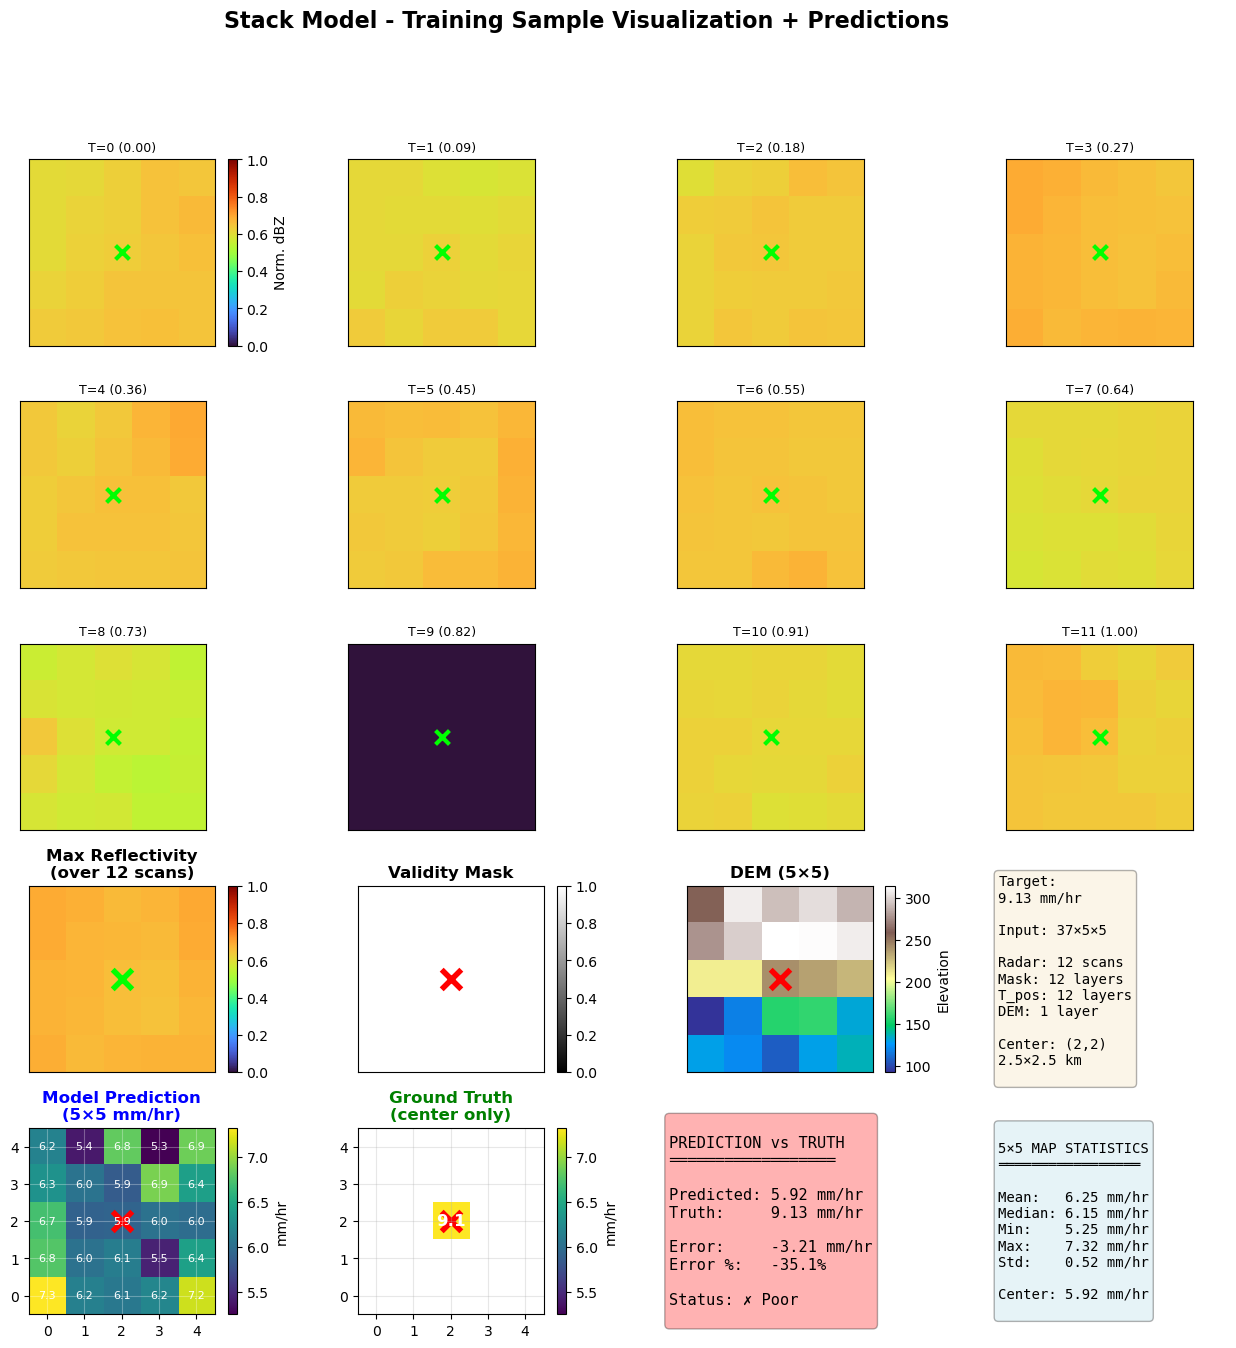

In [29]:
# # WITHOUT model predictions
# for batch in train_loader:
#     visualize_stack_sample(batch, sample_idx=0)
#     break

# Find samples with actual precipitation
for i, batch in enumerate(train_loader):
    # Get the target (log-space precipitation)
    target = batch['target']
    
    # Convert from log space: expm1(log1p(x)) = x
    precip_mm = torch.expm1(target)
    
    # Check if any sample in batch has precipitation > 1mm
    max_precip = precip_mm.max().item()
    if max_precip > 2.0:
        print(f"Batch {i}: max precip = {max_precip:.2f} mm")
        
        # Find which sample in the batch has the most
        best_idx = precip_mm.argmax().item()
        print(f"  Sample {best_idx} has {precip_mm[best_idx].item():.2f} mm")
        
        # Visualize this one
        visualize_stack_sample(batch, sample_idx=best_idx, model=model, device=device)
        break
    
    if i > 50:  # Don't search forever
        print("No high precip found in first 50 batches")
        break

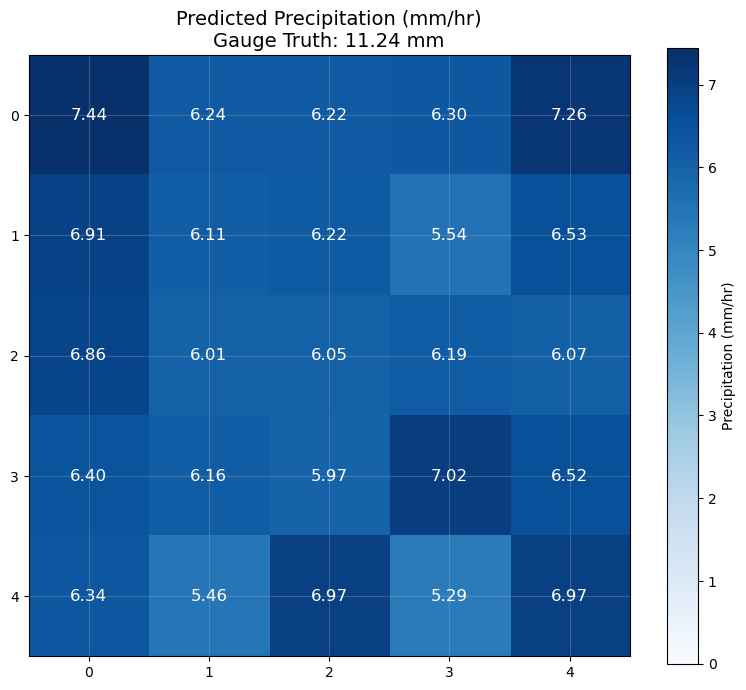

Prediction range: 5.287 - 7.445 mm
Ground truth at gauge: 11.24 mm


In [34]:
import matplotlib.pyplot as plt

# Get a batch with precipitation
for i, batch in enumerate(train_loader):
    precip_mm = torch.expm1(batch['target'])
    if precip_mm.max() > 2.0:
        best_idx = precip_mm.argmax().item()
        break
    if i > 100:
        break

# Get prediction
model.eval()
with torch.no_grad():
    radar_input = batch['radar'][best_idx:best_idx+1].to(device)
    
    if model.add_bias:
        bias = batch['bias_flag'][best_idx:best_idx+1].to(device)
        pred_log = model(radar_input, bias)
    else:
        pred_log = model(radar_input)
    
    # Convert from log space to mm
    pred_mm = torch.expm1(pred_log).squeeze().cpu().numpy()

# Plot just the prediction
fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(pred_mm, cmap='Blues', vmin=0)
ax.set_title(f'Predicted Precipitation (mm/hr)\nGauge Truth: {precip_mm[best_idx].item():.2f} mm', fontsize=14)
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Precipitation (mm/hr)')

# Add values on each cell
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{pred_mm[i, j]:.2f}', ha='center', va='center', 
                fontsize=12, color='black' if pred_mm[i, j] < pred_mm.max()/2 else 'white')

plt.tight_layout()
plt.show()

print(f"Prediction range: {pred_mm.min():.3f} - {pred_mm.max():.3f} mm")
print(f"Ground truth at gauge: {precip_mm[best_idx].item():.2f} mm")